## Matrices in Natural Language Processing (NLP)

Matrices are fundamental data structures in NLP, used to represent and manipulate textual data in a numerical format that machine learning models can understand. They allow us to capture relationships, frequencies, and vector representations of words, documents, and other linguistic units.

### 1. One-Hot Encoding

One-hot encoding is a simple way to represent categorical data, such as words, as numerical vectors. Each word in the vocabulary is assigned a unique index, and its vector representation is a binary vector where only the dimension corresponding to its index is '1', and all others are '0'.

This creates a sparse matrix where most values are zero, which can be inefficient for large vocabularies.

In [ ]:
import numpy as np

vocabulary = ['apple', 'banana', 'orange', 'grape']
word_to_index = {word: i for i, word in enumerate(vocabulary)}

def one_hot_encode(word, vocab_size):
    vector = np.zeros(vocab_size)
    if word in word_to_index:
        vector[word_to_index[word]] = 1
    return vector

# Example
word = 'banana'
one_hot_vector = one_hot_encode(word, len(vocabulary))
print(f"One-hot encoding for '{word}': {one_hot_vector}")

word = 'mango'
one_hot_vector_unknown = one_hot_encode(word, len(vocabulary))
print(f"One-hot encoding for unknown word '{word}': {one_hot_vector_unknown}")

# A sentence represented as a matrix of one-hot vectors
sentence = ['apple', 'orange', 'apple']
one_hot_matrix = np.array([one_hot_encode(w, len(vocabulary)) for w in sentence])
print("\nOne-hot matrix for sentence:")
print(one_hot_matrix)

### 2. Word Embeddings (Dense Vector Representations)

Word embeddings are dense, low-dimensional vector representations of words that capture semantic and syntactic relationships. Words with similar meanings are mapped to nearby points in the vector space. These are typically learned from large text corpora using models like Word2Vec, GloVe, FastText, or contextual embeddings from BERT, GPT, etc.

When we refer to a 'word embedding matrix', we often mean a lookup table where each row is the embedding vector for a particular word in the vocabulary.

### 2.1 Word Embeddings: The 'Word to Vector' Concept in Detail

Word embeddings are dense vector representations of words that capture their semantic and syntactic properties. Unlike one-hot encoding, which treats each word as an independent, discrete entity (leading to high-dimensional, sparse vectors), word embeddings map words into a continuous vector space where words with similar meanings are located closer to each other.

**Why Word Embeddings?**

1.  **Dimensionality Reduction:** They convert sparse, high-dimensional one-hot vectors into dense, low-dimensional vectors (typically 50-300 dimensions), making computations more efficient.
2.  **Semantic Meaning:** They capture nuanced relationships between words. For example, the vector for 'king' might be similar to 'queen', and the relationship between 'king' and 'man' might be similar to 'queen' and 'woman' (`king - man + woman ≈ queen`).
3.  **Generalization:** Models trained with embeddings can generalize better because words with similar meanings have similar representations, allowing knowledge learned from one word to be applied to another.

**How are they Generated?**

Word embeddings are learned from large corpora of text using various techniques:

*   **Prediction-based models (e.g., Word2Vec, FastText):** These models try to predict a word based on its context (Continuous Bag-of-Words - CBOW) or predict the context based on a word (Skip-gram).
*   **Count-based models (e.g., GloVe - Global Vectors for Word Representation):** These models build on co-occurrence statistics, but instead of just raw counts, they learn vectors such that their dot product equals the logarithm of the words' co-occurrence probability.
*   **Contextual Embeddings (e.g., BERT, GPT, ELMo):** More recent models generate word embeddings that are *context-dependent*. This means the embedding for a word like 'bank' will differ depending on whether it's used in the context of a 'river bank' or a 'financial bank'. These are often derived from large pre-trained Transformer models.

#### Example: Word2Vec Demonstration (Expanded)

Let's expand on the Word2Vec example to demonstrate more properties of word embeddings, such as finding most similar words and vector analogies.

In [ ]:
import gensim.downloader as api
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# --- Option 1: Train a small model (as before, but adding more words for richer examples) ---
sentences_w2v = [
    ['king', 'is', 'a', 'man'],
    ['queen', 'is', 'a', 'woman'],
    ['man', 'is', 'to', 'woman', 'as', 'king', 'is', 'to', 'queen'],
    ['he', 'is', 'the', 'king'],
    ['she', 'is', 'the', 'queen'],
    ['prince', 'is', 'a', 'boy'],
    ['princess', 'is', 'a', 'girl'],
    ['apple', 'is', 'a', 'fruit'],
    ['banana', 'is', 'a', 'fruit'],
    ['computer', 'is', 'a', 'machine']
]

# Train a simple Word2Vec model
model_small = Word2Vec(sentences_w2v, vector_size=10, window=2, min_count=1, workers=4)
print("--- Small Word2Vec Model Examples ---")

# Get word vectors
king_vec = model_small.wv['king']
queen_vec = model_small.wv['queen']
man_vec = model_small.wv['man']
woman_vec = model_small.wv['woman']

print(f"Embedding for 'king': {king_vec[:5]}...\n") # Print first 5 dimensions

# Semantic similarity
print(f"Similarity between 'king' and 'queen': {model_small.wv.similarity('king', 'queen'):.4f}")
print(f"Similarity between 'king' and 'fruit': {model_small.wv.similarity('king', 'fruit'):.4f}")

# Finding most similar words
if 'king' in model_small.wv:
    print("Most similar to 'king':", model_small.wv.most_similar('king'))
if 'fruit' in model_small.wv:
    print("Most similar to 'fruit':", model_small.wv.most_similar('fruit'))

# Vector Analogies (King - Man + Woman = ?)
# Note: With a small corpus, results are often not perfect but demonstrate the concept
if all(word in model_small.wv for word in ['king', 'man', 'woman']):
    result = model_small.wv.most_similar(positive=['king', 'woman'], negative=['man'])
    print(f"\nAnalogy: 'king' - 'man' + 'woman' = {result[0][0]} (score: {result[0][1]:.4f})")

# --- Option 2: Using a pre-trained model (for more robust examples) ---
print("\n--- Using Pre-trained GloVe Model (may take a moment to download) ---")
try:
    # Download a pre-trained GloVe model (e.g., 'glove-wiki-gigaword-50')
    # This is a large file, so it might take a while the first time.
    glove_model = api.load("glove-wiki-gigaword-50")
    print("GloVe model loaded.")

    # Get word vectors from pre-trained model
    king_vec_glove = glove_model['king']
    queen_vec_glove = glove_model['queen']
    man_vec_glove = glove_model['man']
    woman_vec_glove = glove_model['woman']

    print(f"Embedding for 'king' (GloVe): {king_vec_glove[:5]}...\n")

    # Semantic similarity
    print(f"Similarity between 'king' and 'queen' (GloVe): {glove_model.similarity('king', 'queen'):.4f}")
    print(f"Similarity between 'king' and 'fruit' (GloVe): {glove_model.similarity('king', 'fruit'):.4f}")

    # Finding most similar words
    print("Most similar to 'king' (GloVe):", glove_model.most_similar('king'))
    print("Most similar to 'doctor':", glove_model.most_similar('doctor'))

    # Vector Analogies (King - Man + Woman = ?)
    result_glove = glove_model.most_similar(positive=['king', 'woman'], negative=['man'])
    print(f"\nAnalogy (GloVe): 'king' - 'man' + 'woman' = {result_glove[0][0]} (score: {result_glove[0][1]:.4f})")

except Exception as e:
    print(f"Could not load pre-trained GloVe model. This is common if the internet is unstable or the download fails. Error: {e}")
    print("Continuing with only the small Word2Vec model results.")

The output from the GloVe model demonstrates the power of word embeddings from large corpora. The 'king' - 'man' + 'woman' analogy very accurately results in 'queen', showing how these vectors capture complex relational semantics.

In [ ]:
from gensim.models import Word2Vec

# Sample corpus
sentences = [
    ['king', 'is', 'a', 'man'],
    ['queen', 'is', 'a', 'woman'],
    ['man', 'is', 'to', 'woman', 'as', 'king', 'is', 'to', 'queen'],
    ['he', 'is', 'the', 'king'],
    ['she', 'is', 'the', 'queen']
]

# Train a simple Word2Vec model
model = Word2Vec(sentences, vector_size=10, window=2, min_count=1, workers=4)

# Get word vectors
king_vector = model.wv['king']
queen_vector = model.wv['queen']
man_vector = model.wv['man']
woman_vector = model.wv['woman']

print(f"Embedding for 'king': {king_vector}\n")
print(f"Embedding for 'queen': {queen_vector}\n")

# Semantic similarity (cosine similarity)
print(f"Similarity between 'king' and 'queen': {model.wv.similarity('king', 'queen')}")
print(f"Similarity between 'king' and 'man': {model.wv.similarity('king', 'man')}")
print(f"Similarity between 'king' and 'woman': {model.wv.similarity('king', 'woman')}")

# The entire embedding layer in a neural network can be viewed as a large matrix
# where each row is a word's embedding.
# For example, if we have 5 words and vector_size=10, the embedding matrix would be 5x10.
embedding_matrix_shape = (len(model.wv.index_to_key), model.wv.vector_size)
print(f"\nShape of the embedding matrix (conceptual): {embedding_matrix_shape}")

### 3. Term-Document Matrix (TF-IDF)

A Term-Document Matrix (TDM) represents the occurrence of terms (words) in a collection of documents. Each row typically corresponds to a unique term, and each column corresponds to a document. The values in the matrix can be raw term frequencies (TF), binary presence/absence, or more sophisticated metrics like TF-IDF (Term Frequency-Inverse Document Frequency).

TF-IDF weighs terms based on their frequency in a document and their rarity across the entire corpus, giving more importance to terms that are distinctive to a document.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

documents = [
    "The cat sat on the mat.",
    "The dog ran in the park.",
    "The cat and dog played together."
]

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer()

# Fit and transform the documents to a TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(documents)

# Get feature names (words)
feature_names = vectorizer.get_feature_names_out()

# Convert to a dense array and then to a DataFrame for better visualization
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

print("TF-IDF Matrix:")
display(tfidf_df)

### 4. Co-occurrence Matrix

A co-occurrence matrix captures how often words appear together within a specified context window (e.g., within the same sentence or a few words apart). Each row and column corresponds to a word in the vocabulary, and the cell `(i, j)` contains the number of times word `i` and word `j` co-occur.

These matrices are foundational for older word embedding models like GloVe.

In [ ]:
from collections import defaultdict
import itertools

text = "i like apples and i like bananas and i like oranges"
words = text.split()
vocabulary = sorted(list(set(words)))
word_to_index = {word: i for i, word in enumerate(vocabulary)}

vocab_size = len(vocabulary)
co_occurrence_matrix = np.zeros((vocab_size, vocab_size))

window_size = 2 # words within this distance from each other co-occur

for i, target_word in enumerate(words):
    for j in range(max(0, i - window_size), min(len(words), i + window_size + 1)):
        if i == j: # Don't count word co-occurring with itself
            continue
        context_word = words[j]
        co_occurrence_matrix[word_to_index[target_word], word_to_index[context_word]] += 1

co_occurrence_df = pd.DataFrame(co_occurrence_matrix, index=vocabulary, columns=vocabulary)

print("Co-occurrence Matrix (window_size=2):")
display(co_occurrence_df)

### 5. Confusion Matrix

While not directly used for text representation, a confusion matrix is a crucial matrix in NLP for evaluating the performance of classification models (e.g., sentiment analysis, spam detection). It displays the number of correct and incorrect predictions made by a model against the true labels.

It helps to visualize the performance of an algorithm and identify where it's making mistakes (e.g., confusing positive for negative).



In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Example data for a binary classification task (e.g., spam detection)
# True labels: 1 for spam, 0 for not spam
y_true = [0, 1, 0, 0, 1, 1, 0, 1, 0, 0]
# Predicted labels by a model
y_pred = [0, 1, 0, 1, 1, 0, 0, 1, 0, 0]

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix Example')
plt.show()

### 6. Matrices in Deep Learning (Transformers)

In modern deep learning models for NLP, especially Transformer architectures (like BERT, GPT), matrices are ubiquitous:

*   **Input Embeddings:** Words are first converted into embedding vectors, which form a matrix representing the input sequence.
*   **Positional Encodings:** Another matrix is added to the input embeddings to convey word order information.
*   **Weight Matrices:** Every linear layer, feed-forward network, and attention mechanism in a Transformer involves matrix multiplications with learned weight matrices.
*   **Attention Scores:** The core of the Transformer, the self-attention mechanism, computes similarity scores between different parts of the input sequence. These scores are represented as matrices (Query, Key, Value matrices and their products).
*   **Hidden States:** The internal representations of the text at various layers are also matrices.

Essentially, the entire process within a deep learning NLP model is a series of complex matrix operations.

### 7. Multilayer Perceptron (MLP) for Word Co-occurrence using One-Hot Encoding

Let's demonstrate how one-hot encoded word representations can be used as input to a simple Multilayer Perceptron (MLP) for a task like predicting word co-occurrence within a given context window. This example will cover:

*   **Input:** Generating one-hot encoded pairs of words.
*   **Architecture:** Defining a basic MLP model.
*   **Loss:** Using a differentiable loss function suitable for binary classification.
*   **Output:** The model's prediction for co-occurrence.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# --- 1. Data Preparation: One-Hot Encoded Inputs for Co-occurrence ---

# Define a simple vocabulary
vocabulary = ['i', 'like', 'apples', 'and', 'bananas', 'oranges', 'dogs', 'cats']
word_to_index = {word: i for i, word in enumerate(vocabulary)}
vocab_size = len(vocabulary)

def one_hot_encode(word, vocab_size, word_to_index_map):
    vector = np.zeros(vocab_size)
    if word in word_to_index_map:
        vector[word_to_index_map[word]] = 1
    return vector

# Sample text to generate co-occurrence pairs
text = "i like apples and i like bananas and i like oranges but i like dogs more than cats"
words_in_text = text.split()

# Generate word pairs and labels (1 for co-occurring, 0 for not)
window_size = 2
pairs_input = []
pairs_label = []

# Positive examples (co-occurring words)
for i, target_word in enumerate(words_in_text):
    for j in range(max(0, i - window_size), min(len(words_in_text), i + window_size + 1)):
        if i == j: continue
        context_word = words_in_text[j]

        # Concatenate one-hot vectors for the pair
        oh_target = one_hot_encode(target_word, vocab_size, word_to_index)
        oh_context = one_hot_encode(context_word, vocab_size, word_to_index)

        combined_oh = np.concatenate((oh_target, oh_context))
        pairs_input.append(combined_oh)
        pairs_label.append(1) # Co-occurring

# Add some negative examples (randomly chosen non-co-occurring pairs)
import random
num_negative_samples = len(pairs_input) # roughly equal number of positive/negative
for _ in range(num_negative_samples):
    word1 = random.choice(vocabulary)
    word2 = random.choice(vocabulary)
    # Ensure they are different and not already a positive pair (simplistic check)
    if word1 == word2: continue

    # Check if (word1, word2) or (word2, word1) is a positive pair in original context
    # For simplicity, we'll just add random different words, assuming low chance of true co-occurrence

    oh_word1 = one_hot_encode(word1, vocab_size, word_to_index)
    oh_word2 = one_hot_encode(word2, vocab_size, word_to_index)
    combined_oh = np.concatenate((oh_word1, oh_word2))
    pairs_input.append(combined_oh)
    pairs_label.append(0) # Not co-occurring

# Convert to PyTorch tensors
X = torch.tensor(np.array(pairs_input), dtype=torch.float32)
y = torch.tensor(np.array(pairs_label), dtype=torch.float32).unsqueeze(1) # For BCEWithLogitsLoss

print(f"Shape of input features (X): {X.shape}") # Should be (num_samples, 2 * vocab_size)
print(f"Shape of labels (y): {y.shape}")
print(f"Example input (one-hot for two words):")
print(X[0])
print(f"Example label: {y[0].item()}")

#### MLP Architecture

Our MLP will take the concatenated one-hot vectors as input. It will consist of:

*   **Input Layer:** Receives the `2 * vocab_size` features (one-hot for word 1 concatenated with one-hot for word 2).
*   **Hidden Layers:** One or more layers with non-linear activation functions (e.g., ReLU) to learn complex relationships.
*   **Output Layer:** A single neuron with a sigmoid activation for binary classification, producing a probability of co-occurrence.

In [ ]:
class CoOccurrenceMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CoOccurrenceMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  # First hidden layer
        self.relu = nn.ReLU()                         # Non-linear activation
        self.fc2 = nn.Linear(hidden_size, hidden_size) # Second hidden layer
        self.fc3 = nn.Linear(hidden_size, output_size) # Output layer
        self.sigmoid = nn.Sigmoid()                   # Sigmoid for binary probability

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        out = self.sigmoid(out) # Output a probability between 0 and 1
        return out

# Define model parameters
input_dim = 2 * vocab_size  # two one-hot vectors concatenated
hidden_dim = 64
output_dim = 1              # Binary classification (co-occurrence or not)

# Instantiate the model
model = CoOccurrenceMLP(input_dim, hidden_dim, output_dim)
print("MLP Architecture:")
print(model)

#### Loss Function and Differentiability

For binary classification tasks like co-occurrence prediction, a common and differentiable loss function is **Binary Cross-Entropy Loss** (or `BCEWithLogitsLoss` in PyTorch, which is numerically more stable). This loss function measures the difference between the predicted probabilities and the true binary labels. Since all operations within the MLP (linear layers, ReLU, Sigmoid) are differentiable, the loss function is also differentiable with respect to the model's parameters, allowing us to use gradient-based optimization algorithms (like Stochastic Gradient Descent or Adam) to train the model.

In [ ]:
# --- 3. Training the MLP ---

# Define Loss Function and Optimizer
criterion = nn.BCELoss() # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Simple Training Loop
num_epochs = 100
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X)
    loss = criterion(outputs, y)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 20 == 0:
        print (f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# --- 4. Example Output/Prediction ---

print("\n--- Example Predictions ---")

# Test a co-occurring pair: 'i' and 'like'
word1_oh = one_hot_encode('i', vocab_size, word_to_index)
word2_oh = one_hot_encode('like', vocab_size, word_to_index)
input_pair = torch.tensor(np.concatenate((word1_oh, word2_oh)), dtype=torch.float32).unsqueeze(0) # Add batch dimension

model.eval() # Set model to evaluation mode
with torch.no_grad():
    prediction = model(input_pair).item()
print(f"Co-occurrence probability for ('i', 'like'): {prediction:.4f} (Expected: High)")

# Test a non-co-occurring pair: 'apples' and 'dogs'
word1_oh = one_hot_encode('apples', vocab_size, word_to_index)
word2_oh = one_hot_encode('dogs', vocab_size, word_to_index)
input_pair = torch.tensor(np.concatenate((word1_oh, word2_oh)), dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    prediction = model(input_pair).item()
print(f"Co-occurrence probability for ('apples', 'dogs'): {prediction:.4f} (Expected: Low)")

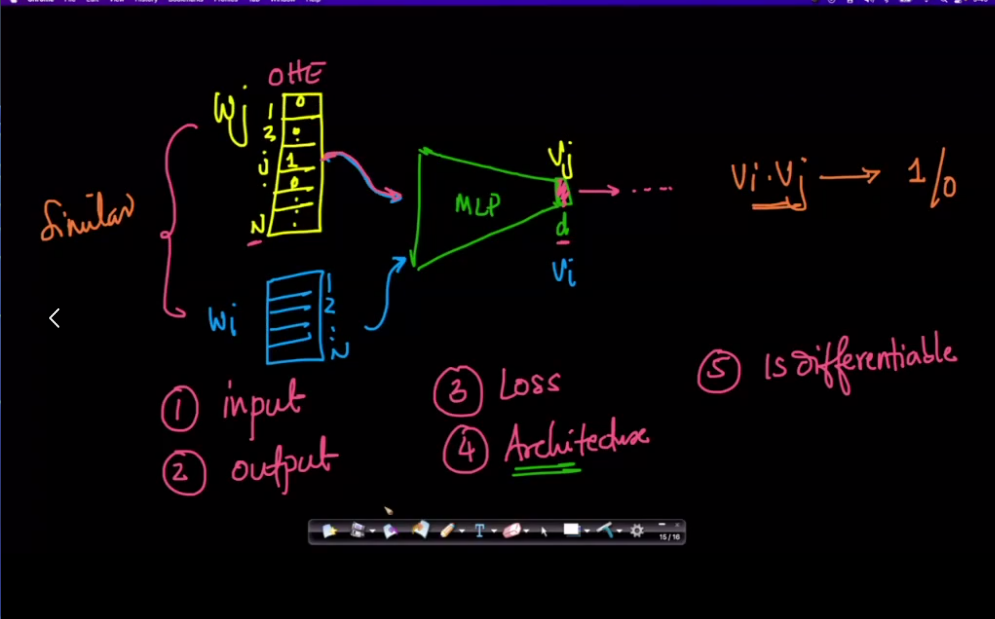

## Clarifying 'Doc-Word' and 'Word-Word' Co-occurrence

To directly address your question about 'doc-word' and 'word-word' co-occurrence in context:

### Doc-Word Co-occurrence (Term-Document Matrix)

**Definition:** 'Doc-word' co-occurrence refers to the relationship between a specific term (word) and a document within a corpus. It measures how often a particular word appears in a given document or across a collection of documents.

**In the Context of Matrices:** This is typically represented by a **Term-Document Matrix**, where rows represent unique terms and columns represent documents. The values in the matrix indicate the presence or frequency (e.g., raw counts, TF-IDF scores) of each term in each document.

**Reference in this Notebook:** Please see **Section 3: Term-Document Matrix (TF-IDF)** (Code Cell `66cde810`) for a practical example.

### Word-Word Co-occurrence in Context/Window

**Definition:** 'Word-word' co-occurrence in context (or within a window) refers to how often two words appear together within a specified proximity (a 'context window') in a text. This helps capture semantic relationships, as words that frequently co-occur often share similar meanings or grammatical roles.

**In the Context of Matrices:** This is typically represented by a **Co-occurrence Matrix**, where both rows and columns represent unique words in the vocabulary. The value at `(i, j)` in the matrix indicates the number of times word `i` and word `j` appeared together within the defined context window.

**Reference in this Notebook:**
*   **Section 4: Co-occurrence Matrix** (Code Cell `7c3530f2`) provides a direct implementation of how to build such a matrix.
*   **Section 7: Multilayer Perceptron (MLP) for Word Co-occurrence** (Code Cell `cbf0a2e0` and subsequent cells) demonstrates how to use these co-occurrence concepts, particularly one-hot encoded word pairs, as input to a neural network to predict if words co-occur.

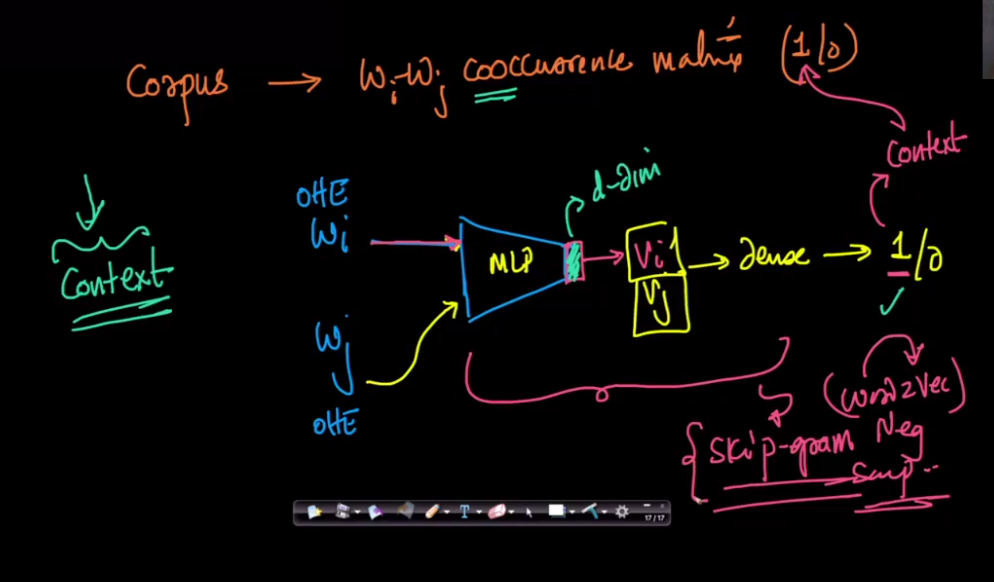